# Sesión 07 — Diseño de red de acceso sobre San Isidro

Notebook de diseño construido **fase por fase** siguiendo el flujo
profesional (teoría y justificación de cada número: `index.md` de la
sesión). El esbozo exploratorio previo vive en `test_scene.ipynb`.

Kernel: `ran-design` (sionna 2.x). Ejecución headless:
`python -m nbconvert --to notebook --execute --inplace design.ipynb`

In [1]:
# ---- Preparación del entorno (ejecutar SIEMPRE esta celda primero) ----
# ESCENA es la única variable que cambias: el nombre del mapa que proporciona el curso.
# Si te asignaron otro mapa, cambia SOLO esta línea (p. ej. "miraflores").
ESCENA = "san_isidro"

# En Google Colab: instala Sionna RT y descarga el mapa del sitio del
# curso (~0.5 MB). En un entorno local: no hace nada.
# Colab: usar runtime con GPU (Entorno de ejecución -> Cambiar tipo de
# entorno -> T4 GPU); el mapa consolidado de la Fase 6 en CPU tarda MUCHO más.
import importlib.util, os

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ModuleNotFoundError:
    EN_COLAB = False

if EN_COLAB:
    if importlib.util.find_spec("sionna") is None:
        %pip install -q sionna-rt
    if not os.path.exists(f"escenas/{ESCENA}/{ESCENA}.xml"):
        !wget -q https://ollerenac.github.io/wireless-communication-systems/sessions/07-network-design/escenas/{ESCENA}.zip
        !unzip -qo {ESCENA}.zip -d escenas && rm {ESCENA}.zip
    os.makedirs("resultados", exist_ok=True)
    print(f"Colab listo: Sionna RT instalado, mapa '{ESCENA}' descargado.")
else:
    print(f"entorno local (kernel ran-design) — mapa '{ESCENA}' del repo")
assert os.path.exists(f"escenas/{ESCENA}/{ESCENA}.xml"), \
    f"no se encontró escenas/{ESCENA}/{ESCENA}.xml — ¿nombre correcto?"

entorno local (kernel ran-design) — mapa 'san_isidro' del repo


## Fase 0 — Requisitos del proyecto

Todo el diseño se verifica contra estas metas (tabla completa y
justificación en `index.md` §Fase 0). Son constantes del proyecto:
si el negocio las cambia, el diseño se recalcula — por eso viven en
una celda propia al inicio.

In [2]:
# ============ REQUISITOS (Fase 0) — contrato del diseño ============
import math

# --- Primero, la demanda de hora cargada (fórmula de §0.4) ---
# Hipótesis de negocio explícitas: población presente en hora cargada
# (distrito financiero), participación y consumo; f_BH declarada.
personas_km2 = 25_000   # población presente en hora cargada (TdR)
market_share = 0.30     # participación (TdR)
gb_mes       = 10       # consumo mensual (TdR)
f_bh         = 0.10     # fracción de hora cargada, declarada (§0.4)
kbps_por_abonado = gb_mes * 8e9 * f_bh / (30 * 3600) / 1e3
demanda = personas_km2 * market_share * kbps_por_abonado / 1e3   # Mbps/km2

# --- Luego, el contrato: R5 sale de la demanda, no al revés ---
REQ = {
    # R1 — área de servicio: el mapa elegido en la celda de preparación
    "escena":            f"escenas/{ESCENA}/{ESCENA}.xml",
    "area_km2":          1.32 * 0.83,
    # R2 — cobertura de control
    "rsrp_min_dbm":      -110.0,
    "rsrp_prob":         0.95,
    # R3 — calidad de datos
    "sinr_min_db":       0.0,
    "sinr_prob":         0.90,
    # R4 — target de borde dado por la guia del operador (§0.3, ref. NGMN
    #   "50 Mbps everywhere"); UL = mayor de la columna UL (Tabla 0.3) + margen.
    #   Verificacion del minimo tecnico: videollamada + oficina en la nube -> DL 5 / UL 4,
    #   cubiertos por 50/5.
    "thr_borde_dl_mbps": 50.0,
    "thr_borde_ul_mbps": 5.0,
    # R5 — capacidad agregada en hora cargada
    "capacidad_mbps_km2": math.ceil(demanda / 100) * 100,
    # (R6 — servicios eMBB+VoNR y latencia: se garantiza por arquitectura/QoS,
    #  no hay mapa del trazador que lo verifique -> no entra al dict)
    # R7 — espectro licenciado
    "banda":             "n78",
    "fc_hz":             3.5e9,
    "bw_hz":             100e6,
    # R8 — restricciones de despliegue
    "max_sitios":        6,
    "p_tx_dbm_max":      44.0,
}

print(f"{kbps_por_abonado:.0f} kbps/abonado en hora cargada "
      f"-> demanda {demanda:.0f} Mbps/km2 -> R5 = {REQ['capacidad_mbps_km2']:.0f} "
      f"(redondeo al centenar)")
assert demanda <= REQ["capacidad_mbps_km2"], "R5 no cubre la demanda estimada"


74 kbps/abonado en hora cargada -> demanda 556 Mbps/km2 -> R5 = 600 (redondeo al centenar)


## Fase 1 — Estrategia de espectro

Dos cálculos que fijan el resto del diseño (teoría en `index.md` §Fase 1):

1. **Frecuencia → sitios**: el delta de pérdida entre bandas se convierte en
   factor de radio ($10^{\Delta/10n}$) y de área — la razón física de las
   capas de espectro.
2. **TDD → ancho de banda efectivo**: el patrón DDDSU reparte el tiempo;
   DL y UL no ven los mismos 100 MHz.

In [3]:
import numpy as np

# ---- Cálculo 1: bandas candidatas vs n78 (referencia del proyecto) ----
N_PROP = 3.8                       # exponente de propagación urbano denso
bandas_hz = {"n28 (700 MHz)": 0.7e9, "n1 (2.1 GHz)": 2.1e9,
             "n78 (3.5 GHz)": 3.5e9, "n258 (26 GHz)": 26e9}

fc_ref = REQ["fc_hz"]
print(f"{'banda':<15} {'Δpérdida':>9} {'radio rel.':>10} {'sitios rel.':>11}")
for nombre, f in bandas_hz.items():
    delta_db = 20*np.log10(f/fc_ref)          # solo el término de frecuencia
    r_rel = 10**(-delta_db/(10*N_PROP))       # MAPL fijo -> radio relativo
    sitios_rel = 1/r_rel**2                   # sitios ∝ 1/área de celda
    print(f"{nombre:<15} {delta_db:>+7.1f}dB {r_rel:>9.2f}x {sitios_rel:>10.2f}x")

print("\nLección: la banda se paga en sitios — o al revés.")

banda            Δpérdida radio rel. sitios rel.
n28 (700 MHz)     -14.0dB      2.33x       0.18x
n1 (2.1 GHz)       -4.4dB      1.31x       0.58x
n78 (3.5 GHz)      +0.0dB      1.00x       1.00x
n258 (26 GHz)     +17.4dB      0.35x       8.26x

Lección: la banda se paga en sitios — o al revés.


In [4]:
# ---- Cálculo 2: patrón TDD DDDSU -> ancho de banda efectivo ----
# De cada 5 slots: 3 DL + 1 especial (~57% de símbolos DL) + 1 UL
slots = {"DL": 3, "S": 1, "UL": 1}
frac_dl = (slots["DL"] + 0.57*slots["S"]) / sum(slots.values())
frac_ul = slots["UL"] / sum(slots.values())

ESPECTRO = {                       # decisión de la Fase 1 — hereda el diseño
    "patron_tdd":   "DDDSU",
    "frac_dl":      frac_dl,
    "frac_ul":      frac_ul,
    "bw_dl_ef_hz":  REQ["bw_hz"] * frac_dl,
    "bw_ul_ef_hz":  REQ["bw_hz"] * frac_ul,
    "scs_hz":       30e3,          # numerologia mu=1 (S03); CP 2.3 us >> DS 60 ns medido
}
print(f"DL: {frac_dl:.0%} del tiempo -> {ESPECTRO['bw_dl_ef_hz']/1e6:.0f} MHz efectivos")
print(f"UL: {frac_ul:.0%} del tiempo -> {ESPECTRO['bw_ul_ef_hz']/1e6:.0f} MHz efectivos")
print("El UE pierde dos veces: en potencia (23 vs 44 dBm) y en tiempo (1 slot de 5).")

DL: 71% del tiempo -> 71 MHz efectivos
UL: 20% del tiempo -> 20 MHz efectivos
El UE pierde dos veces: en potencia (23 vs 44 dBm) y en tiempo (1 slot de 5).


## Fase 2 — Dimensionamiento por cobertura

Link budget → MAPL → radio (UMa 3GPP) → sitios por cobertura.
Teoría en `index.md` §Fase 2; la mecánica per-RE en `rsrp-rsrq-sinr.md`.

Regla de la fase: el radio real lo fija el **peor** de los dos enlaces
(DL de control vs UL de datos).

In [5]:
# ---- Link budget DL (cobertura de control, R2) ----
N_PRB = 273                                          # 100 MHz @ SCS 30 kHz (TS 38.101)
n_sc = N_PRB * 12                                    # subportadoras utilizables
EPRE = REQ["p_tx_dbm_max"] - 10*np.log10(n_sc)       # dBm por RE: el 44 se reparte
G_TX, M_SHADOW = 16.0, 9.0                           # dBi macro / margen 95%, sigma 8 dB

mapl_dl = EPRE + G_TX + (-REQ["rsrp_min_dbm"]) - M_SHADOW
print(f"EPRE = {EPRE:.1f} dBm  (los 44 dBm entre {n_sc} subportadoras)")
print(f"MAPL DL (control) = {mapl_dl:.1f} dB")

# ---- Link budget UL (datos, R4-UL) ----
# El UE concentra 23 dBm en pocos PRB asignados (aqui 5 MHz) — su gran defensa
P_UE, NF_BS, SNR_UL_MIN, BW_UL = 23.0, 5.0, 0.0, 5e6
sens_bs = -174 + 10*np.log10(BW_UL) + NF_BS + SNR_UL_MIN
mapl_ul = P_UE + G_TX - sens_bs - M_SHADOW           # misma antena BS recibe
print(f"sensibilidad BS = {sens_bs:.1f} dBm  ->  MAPL UL = {mapl_ul:.1f} dB")

MAPL = min(mapl_dl, mapl_ul)
limitante = "DL control" if mapl_dl < mapl_ul else "UL datos"
print(f"\nMAPL de diseño = {MAPL:.1f} dB  (enlace limitante: {limitante})")

EPRE = 8.8 dBm  (los 44 dBm entre 3276 subportadoras)
MAPL DL (control) = 125.8 dB
sensibilidad BS = -102.0 dBm  ->  MAPL UL = 132.0 dB

MAPL de diseño = 125.8 dB  (enlace limitante: DL control)


In [6]:
# ---- ¿De dónde salió M_SHADOW = 9? (integral de Jakes, numérica) ----
# Receta de diseño: (1) sigma del escenario (38.901 tabla 7.4.1-1, o drive
# test), (2) meta DE ÁREA -> prob. de borde equivalente -> M = z_borde*sigma.
# Error clásico: usar z(meta de área) directo — da el margen "de borde",
# una oferta más cara que la del contrato.
from statistics import NormalDist
Phi, z_de = NormalDist().cdf, NormalDist().inv_cdf

def cobertura_area(M_db, sigma_db, n_exp):
    """fracción del área de la celda sobre el umbral (Jakes, numérico)"""
    r = np.linspace(1e-4, 1, 2000)              # radio normalizado al borde
    margen_r = M_db + 10*n_exp*np.log10(1/r)    # el interior regala margen
    p = np.array([Phi(m/sigma_db) for m in margen_r])
    return np.trapezoid(2*r*p, r)               # integral en área (2r dr)

def margen_para_area(meta, sigma_db, n_exp):
    lo, hi = -10.0, 30.0
    for _ in range(50):
        mid = (lo + hi)/2
        lo, hi = (mid, hi) if cobertura_area(mid, sigma_db, n_exp) < meta else (lo, mid)
    return (lo + hi)/2

SIGMA_SF = 8.0                     # urbano denso (Okumura/COST-231); 38.901 UMa NLOS: 6
print(f"sigma={SIGMA_SF} dB, n={N_PROP}")
print(f"{'meta área':>10} {'M [dB]':>7} {'borde equiv.':>13} {'z(área)·sigma ingenuo':>22}")
for meta in [0.90, 0.95, 0.99]:
    M = margen_para_area(meta, SIGMA_SF, N_PROP)
    print(f"{meta:>10.0%} {M:>7.1f} {Phi(M/SIGMA_SF):>12.1%} {z_de(meta)*SIGMA_SF:>21.1f}")

M_area = margen_para_area(REQ["rsrp_prob"], SIGMA_SF, N_PROP)
print(f"\nR2 pide {REQ['rsrp_prob']:.0%} de ÁREA -> M = {M_area:.1f} dB; "
      f"el link budget usa M_SHADOW = {M_SHADOW:.0f} (redondeo conservador)")
assert abs(M_area - M_SHADOW) < 1.0, "M_SHADOW inconsistente con la meta R2"

sigma=8.0 dB, n=3.8
 meta área  M [dB]  borde equiv.  z(área)·sigma ingenuo
       90%     5.2        74.1%                  10.3


       95%     8.5        85.5%                  13.2
       99%    14.5        96.5%                  18.6

R2 pide 95% de ÁREA -> M = 8.5 dB; el link budget usa M_SHADOW = 9 (redondeo conservador)


In [7]:
# ---- MAPL -> radio (UMa NLOS, 3GPP TR 38.901) -> sitios por cobertura ----
fc_ghz = REQ["fc_hz"]/1e9

def radio_uma_nlos(mapl_db):
    # PL = 13.54 + 39.08 log10(d) + 20 log10(fc)   [d en m, fc en GHz]
    return 10**((mapl_db - 13.54 - 20*np.log10(fc_ghz)) / 39.08)

r_m = radio_uma_nlos(MAPL)
area_sitio_km2 = 2.6 * (r_m/1e3)**2                 # hexagono trisectorial
n_cobertura = int(np.ceil(REQ["area_km2"] / area_sitio_km2))

print(f"radio de celda      = {r_m:.0f} m")
print(f"area por sitio      = {area_sitio_km2:.2f} km2")
print(f"sitios por COBERTURA = {n_cobertura}  (presupuesto R8: {REQ['max_sitios']})")
assert n_cobertura <= REQ["max_sitios"], "la cobertura sola ya excede R8"

COBERTURA = {"mapl_db": MAPL, "limitante": limitante,
             "radio_m": r_m, "n_sitios": n_cobertura}
# Nota: la Fase 3 hara el cálculo gemelo por capacidad; el diseno final
# necesita max(cobertura, capacidad). La validacion calle-a-calle contra
# la escena real de San Isidro llega en la Fase 6.

radio de celda      = 394 m
area por sitio      = 0.40 km2
sitios por COBERTURA = 3  (presupuesto R8: 6)


## Fase 3 — Dimensionamiento por capacidad

El cálculo gemelo de la Fase 2: sitios para que la red **aguante** R5.
Concepto difícil (qué media usa el scheduler): nota
`de-sinr-a-capacidad.md`. Veredicto de diseño: `max(cobertura, capacidad)`.

In [8]:
# ---- Capacidad de celda y de sitio (DL) ----
SE_CELDA = 2.0      # bit/s/Hz — HIPOTESIS industria SISO conservadora.
                    # ponytail: la Fase 6 la reemplaza con la integral del
                    # mapa SINR ray-traced; queda declarada, no escondida.
OH = 0.22           # overhead: SSB + PDCCH + DMRS (PRBs que no venden bits)

r_celda = SE_CELDA * ESPECTRO["bw_dl_ef_hz"] * (1 - OH)          # bit/s
r_sitio = 3 * r_celda                                            # 3 sectores
print(f"celda: {r_celda/1e6:.0f} Mbps | sitio (3 sectores): {r_sitio/1e6:.0f} Mbps")

# ---- Demanda total vs sitios ----
demanda_total = REQ["capacidad_mbps_km2"] * REQ["area_km2"] * 1e6  # bit/s
n_capacidad = int(np.ceil(demanda_total / r_sitio))

N_SITIOS = max(COBERTURA["n_sitios"], n_capacidad)
print(f"demanda R5: {demanda_total/1e6:.0f} Mbps")
print(f"sitios por CAPACIDAD = {n_capacidad}")
print(f"\nVEREDICTO: max(cobertura={COBERTURA['n_sitios']}, "
      f"capacidad={n_capacidad}) = {N_SITIOS} sitios")
assert N_SITIOS <= REQ["max_sitios"], "el diseño excede el presupuesto R8"

# ---- Margen de crecimiento: ¿cuándo manda la capacidad? ----
instalada = COBERTURA["n_sitios"] * r_sitio
margen = instalada / demanda_total
anios = np.log(margen) / np.log(1.25)          # trafico +25%/año
print(f"capacidad instalada {instalada/1e6:.0f} Mbps -> margen {margen:.2f}x "
      f"≈ {anios:.1f} años al 25%/año")

CAPACIDAD = {"se_celda": SE_CELDA, "overhead": OH, "r_sitio_bps": r_sitio,
             "n_sitios": n_capacidad, "n_final": N_SITIOS}

celda: 111 Mbps | sitio (3 sectores): 334 Mbps
demanda R5: 657 Mbps
sitios por CAPACIDAD = 2

VEREDICTO: max(cobertura=3, capacidad=2) = 3 sitios
capacidad instalada 1002 Mbps -> margen 1.52x ≈ 1.9 años al 25%/año


In [9]:
# ---- La misma verificación, ahora en subida (lección §3.4) ----
# SE_UL = promedio de celda en subida (análogo del 2.0 del DL; menor porque
# los UEs transmiten con menos potencia y los comunes no tienen 256-QAM en
# UL). No confundir con el 1.0 del punto de borde del link budget (§2.4).
SE_UL = 1.2                                     # bit/s/Hz — hipótesis declarada
r_celda_ul = SE_UL * ESPECTRO["bw_ul_ef_hz"] * (1 - OH)
instalada_ul = COBERTURA["n_sitios"] * 3 * r_celda_ul
demanda_ul = 0.15 * demanda_total               # subida típica ~15% de la bajada
print(f"celda UL: {r_celda_ul/1e6:.1f} Mbps | sitio: {3*r_celda_ul/1e6:.0f} Mbps "
      f"| instalados: {instalada_ul/1e6:.0f} Mbps")
print(f"demanda UL (~15% de DL): {demanda_ul/1e6:.0f} Mbps -> "
      f"{'sobra' if instalada_ul > demanda_ul else 'NO ALCANZA'}")
assert instalada_ul > demanda_ul, "el UL limitaría el número de sitios"
CAPACIDAD["r_celda_ul_bps"] = r_celda_ul

celda UL: 18.7 Mbps | sitio: 56 Mbps | instalados: 168 Mbps
demanda UL (~15% de DL): 99 Mbps -> sobra


## Fase 4 — Plan nominal: los 3 sitios aterrizan en San Isidro

Hasta aquí todo fue aritmética; ahora el diseño toca la ciudad. Plan
nominal = posiciones (sobre techos reales, vía ray cast) + sectorización
3×120° + azimuts + downtilt inicial por sitio.
Herramienta: ray tracing sobre la escena real (validación exploratoria a
10⁵ rayos; la consolidada llega en Fase 6).

Convención de azimut en la escena: 0° = +x (este), 90° = +y (norte).

In [10]:
import matplotlib.pyplot as plt
from sionna.rt import load_scene, Transmitter, PlanarArray, RadioMapSolver

scene = load_scene(REQ["escena"])
scene.frequency = REQ["fc_hz"]

# Elemento sectorial 3GPP (65° de haz, ~8 dBi). Nota: el link budget usó
# 16 dBi (elemento + array vertical); aquí modelamos el elemento solo —
# el mapa queda ~8 dB conservador. Se corrige en Fase 6 con el array.
scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="tr38901", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="V")

# altura_en(x, y): ray cast vertical — altura real del techo (0.0 si caes
# en la calle). La antena no flota: techo + 3 m de mástil.
import mitsuba as mi
def altura_en(x, y):
    ray = mi.Ray3f(mi.Point3f(float(x), float(y), 500.0), mi.Vector3f(0.0, 0.0, -1.0))
    si = scene.mi_scene.ray_intersect(ray)
    return float(np.array(si.p.z)[0]) if bool(np.array(si.is_valid())[0]) else 0.0

def mejor_techo(cx, cy, radio=100, paso=20):
    cand = [(cx+dx, cy+dy) for dx in range(-radio, radio+1, paso)
                            for dy in range(-radio, radio+1, paso)]
    return max(cand, key=lambda p: altura_en(*p))

# Plan nominal: 3 sitios (validados por el esbozo) × 3 sectores, cada uno
# posado en el mejor techo cerca de su posición nominal
SITIOS_XY = {n: mejor_techo(cx, cy) for n, (cx, cy) in
             {"s1": (-380, 200), "s2": (350, 230), "s3": (0, -260)}.items()}
SITIOS = {n: [float(x), float(y), altura_en(x, y) + 3.0]
          for n, (x, y) in SITIOS_XY.items()}
AZIMUTS_DEG = [0.0, 120.0, 240.0]
# Downtilt inicial POR SITIO: el haz principal toca suelo a ~0.7 × radio
# de diseño (§4.3) — antena más alta, más tilt. Se barre (uniforme) abajo.
d_obj = 0.7 * COBERTURA["radio_m"]
TILT_DEG = {n: float(np.degrees(np.arctan((p[2] - 1.5) / d_obj)))
            for n, p in SITIOS.items()}
for n, p in SITIOS.items():
    print(f"{n}: ({p[0]:.0f}, {p[1]:.0f}) — antena a {p[2]:.1f} m (techo + 3) "
          f"-> tilt {TILT_DEG[n]:.1f}°")

for sname, pos in SITIOS.items():
    for k, az in enumerate(AZIMUTS_DEG):
        scene.add(Transmitter(f"{sname}c{k}", position=[float(v) for v in pos],
                              orientation=[float(np.deg2rad(az)),
                                           float(np.deg2rad(TILT_DEG[sname])), 0.0],
                              power_dbm=REQ["p_tx_dbm_max"]))
print("celdas:", list(scene.transmitters.keys()))

s1: (-420, 180) — antena a 23.2 m (techo + 3) -> tilt 4.5°
s2: (450, 230) — antena a 35.6 m (techo + 3) -> tilt 7.1°
s3: (80, -260) — antena a 22.6 m (techo + 3) -> tilt 4.4°
celdas: ['s1c0', 's1c1', 's1c2', 's2c0', 's2c1', 's2c2', 's3c0', 's3c1', 's3c2']


cobertura SINR>0 dB: 40.9%  (esbozo iso 3 BS: 71.2% — ahora con 9 celdas sectoriales)
proxy R2: RSRP>=-110 en 37.5% | proxy R3: SINR>0 en 40.9% (exploración — la Fase 6 reporta)


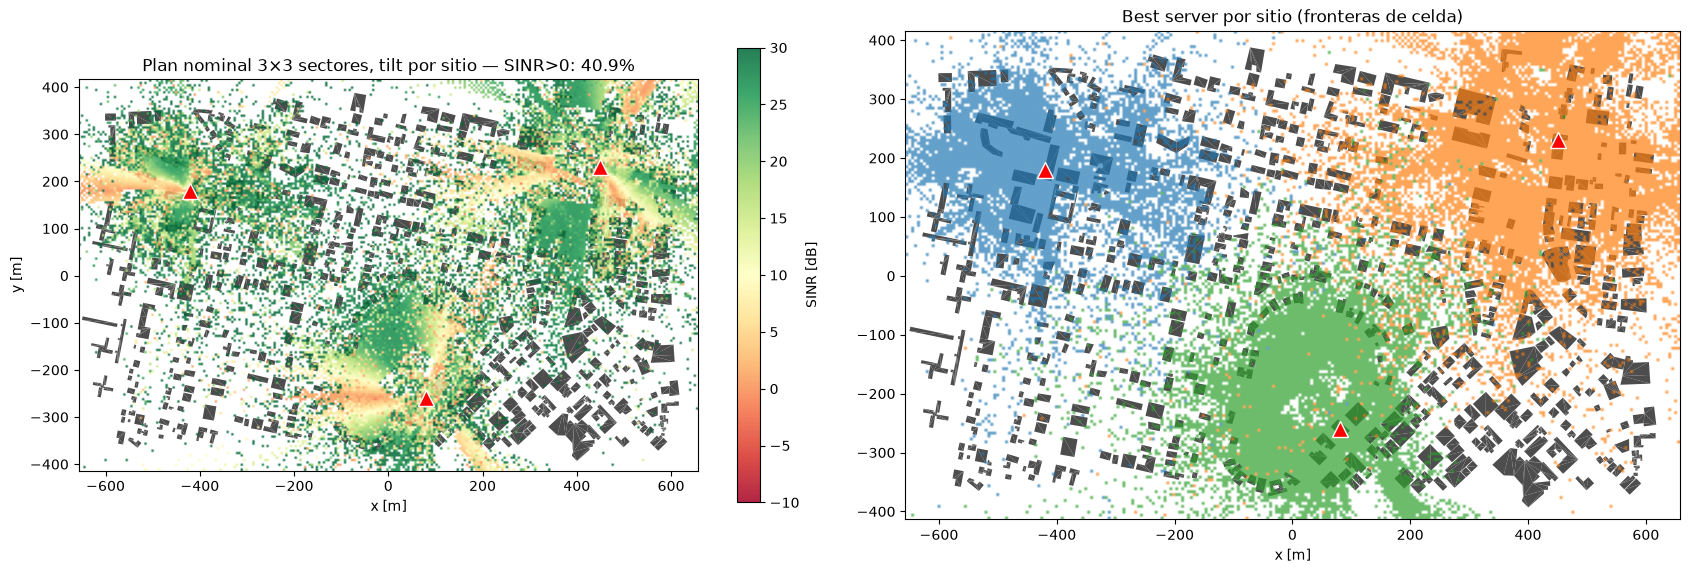

In [11]:
# ---- Mapa del plan nominal: SINR y best-server POR SITIO ----
def mapa(scene):
    return RadioMapSolver()(scene, max_depth=5, cell_size=(5.0, 5.0),
                            samples_per_tx=10**5, diffuse_reflection=True)

def pct_sinr(rm, umbral_db=0.0):
    s = np.array(rm.sinr).max(axis=0)
    return (s > 10**(umbral_db/10)).mean() * 100

rm4 = mapa(scene)
print(f"cobertura SINR>0 dB: {pct_sinr(rm4):.1f}%  "
      f"(esbozo iso 3 BS: 71.2% — ahora con 9 celdas sectoriales)")

# huellas de edificios para los mapas (misma técnica del esbozo)
import mitsuba as mi
from matplotlib.collections import PolyCollection
tris = []
for shape in scene.mi_scene.shapes():
    params = mi.traverse(shape)
    if "vertex_positions" not in params: continue
    V = np.array(params["vertex_positions"]).reshape(-1, 3)
    F = np.array(params["faces"]).reshape(-1, 3)
    if V[:, 2].max() < 1.0: continue
    tris.append(V[F][:, :, :2])
tris = np.concatenate(tris)

cc = np.array(rm4.cell_centers)
extent = [cc[...,0].min(), cc[...,0].max(), cc[...,1].min(), cc[...,1].max()]
sinr9 = np.array(rm4.sinr)                     # [9, ny, nx]
sinr_db4 = 10*np.log10(np.where(sinr9.max(0) > 0, sinr9.max(0), np.nan))
rss9 = np.array(rm4.rss)
sitio_srv = rss9.argmax(axis=0) // 3           # celda ganadora -> sitio
cubierto = rss9.sum(axis=0) > 0

# Métrica gemela: proxy de R2 (§2.5) — RSRP = RSS + 8 dB (corrección de
# array no modelado) - 10log10(n_sc). Sin cobertura = incumplimiento.
rss_dbm4  = 10*np.log10(np.where(rss9.max(0) > 0, rss9.max(0), np.nan)) + 30
rsrp_dbm4 = rss_dbm4 + 8.0 - 10*np.log10(n_sc)
pct_rsrp4 = float((np.nan_to_num(rsrp_dbm4, nan=-999) >= REQ["rsrp_min_dbm"]).mean() * 100)
print(f"proxy R2: RSRP>={REQ['rsrp_min_dbm']:.0f} en {pct_rsrp4:.1f}% | "
      f"proxy R3: SINR>0 en {pct_sinr(rm4):.1f}% (exploración — la Fase 6 reporta)")

fig, axs = plt.subplots(1, 2, figsize=(17, 6))
im0 = axs[0].imshow(sinr_db4, origin="lower", extent=extent,
                    cmap="RdYlGn", vmin=-10, vmax=30, zorder=2, alpha=0.85)
plt.colorbar(im0, ax=axs[0], shrink=0.8, label="SINR [dB]")
axs[0].set_title(f"Plan nominal 3×3 sectores, tilt por sitio — "
                 f"SINR>0: {pct_sinr(rm4):.1f}%")
im1 = axs[1].imshow(np.where(cubierto, sitio_srv, np.nan), origin="lower",
                    extent=extent, cmap="tab10", vmin=0, vmax=9,
                    zorder=2, alpha=0.7)
axs[1].set_title("Best server por sitio (fronteras de celda)")
for ax in axs:
    ax.add_collection(PolyCollection(tris, facecolor="0.3",
                                     edgecolor="none", zorder=1))
    for sname, pos in SITIOS.items():
        ax.plot(pos[0], pos[1], "r^", markersize=12, zorder=3,
                markeredgecolor="white")
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal"); ax.set_xlabel("x [m]")
axs[0].set_ylabel("y [m]")
plt.tight_layout()
plt.savefig("resultados/plan_nominal_mapas.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# ---- Barrido de downtilt: el parámetro de interferencia ----
# geometría: el haz principal toca suelo a d = h/tan(tilt)
for n, p in SITIOS.items():
    h = p[2] - 1.5
    d = h/np.tan(np.deg2rad(TILT_DEG[n]))
    print(f"{n}: h={h:.1f} m, tilt {TILT_DEG[n]:.1f}° -> haz toca suelo a {d:,.0f} m")

resultados_tilt = {}
for t in [0.0, 6.0, 12.0]:
    for sname in SITIOS:
        for k, az in enumerate(AZIMUTS_DEG):
            scene.get(f"{sname}c{k}").orientation = \
                [float(np.deg2rad(az)), float(np.deg2rad(t)), 0.0]
    rm_t = mapa(scene)
    resultados_tilt[t] = (pct_sinr(rm_t), pct_sinr(rm_t, 10.0))
    print(f"tilt {t:>4.0f}°: SINR>0 dB {resultados_tilt[t][0]:.1f}% | "
          f"SINR>10 dB {resultados_tilt[t][1]:.1f}%")

# restaurar el tilt del plan (por sitio)
for sname in SITIOS:
    for k, az in enumerate(AZIMUTS_DEG):
        scene.get(f"{sname}c{k}").orientation = \
            [float(np.deg2rad(az)), float(np.deg2rad(TILT_DEG[sname])), 0.0]

PLAN = {"sitios": SITIOS, "azimuts_deg": AZIMUTS_DEG, "tilt_deg": TILT_DEG,
        "tilt_sweep": resultados_tilt,
        "pct_sinr0": float(pct_sinr(rm4)), "pct_rsrp": pct_rsrp4}

# LECTURA MEDIDA (distinta a la de libro — y ahí está la lección):
# 1) El % de SINR apenas se mueve con el tilt. El signo está verificado
#    (pitch +30° concentra +14 dB de RSS al suelo): el tilt SÍ redistribuye
#    potencia, pero al tiltear TODAS las celdas por igual, señal e
#    interferencia suben juntas y el cociente casi no cambia.
# 2) La regla de libro "tilt = control de interferencia" muerde cuando hay
#    overshooting hacia sitios LEJANOS (macro abierta, haz vertical ~7° de
#    arrays de 8+ elementos). En 1 km² denso con 3 sitios, el scattering
#    urbano domina. El tilt aquí se usa POR CELDA (asimétrico) para
#    corregir invasiones puntuales — no como barrido global uniforme.

s1: h=21.7 m, tilt 4.5° -> haz toca suelo a 276 m
s2: h=34.1 m, tilt 7.1° -> haz toca suelo a 276 m
s3: h=21.1 m, tilt 4.4° -> haz toca suelo a 276 m
tilt    0°: SINR>0 dB 40.7% | SINR>10 dB 31.7%
tilt    6°: SINR>0 dB 40.9% | SINR>10 dB 31.7%
tilt   12°: SINR>0 dB 40.9% | SINR>10 dB 31.6%


## Fase 5 — Planificación detallada: PCI, RACH, TA

El plan nominal (`PLAN`) ya fijó la geometría; ahora los **números que los
procedimientos consumen** (procedimientos del UE y teoría en `index.md`
§Fase 5; el
mecanismo mod-3 en `crs-dos-celdas-pci-mod3.md`):

- **PCI** para las 9 celdas: coloreo mod-3 sobre el grafo de vecindad que
  sale del mapa best-server de la Fase 4.
- **RACH**: N_CS desde el radio de celda de la Fase 2.
- **Tracking areas**: trivial aquí (1), pero con el criterio que escala.

El A3/histéresis ya se midió en el esbozo (`test_scene.ipynb` Parte 4:
8→1 handovers); la Fase 6 lo re-verificará sobre el plan sectorizado.

In [13]:
# ---- PCI planning: coloreo mod-3 de las 9 celdas sobre el best-server ----
# Teoría: index.md §5.2 + nota crs-dos-celdas-pci-mod3.md. Tres reglas:
# sin colisión, sin confusión, y vecinas geográficas sin el mismo mod 3.
# Con 9 celdas y 3 grupos es coloreo de grafos; si no es 3-coloreable,
# se sacrifican las fronteras más cortas.
from collections import Counter

celdas = list(scene.transmitters.keys())            # s1c0 ... s3c2
best = np.where(cubierto, rss9.argmax(axis=0), -1)  # celda ganadora por píxel

# grafo de vecindad: pares de celdas con píxeles adyacentes (4-conexión);
# el peso es la longitud de la frontera común (píxel = 5 m)
frontera = Counter()
for a, b in ((best[:, :-1], best[:, 1:]), (best[:-1, :], best[1:, :])):
    m = (a != b) & (a >= 0) & (b >= 0)
    for i, j in zip(a[m].ravel(), b[m].ravel()):
        frontera[frozenset((int(i), int(j)))] += 1

vecinos = {i: set() for i in range(len(celdas))}
for par in frontera:
    i, j = tuple(par)
    vecinos[i].add(j); vecinos[j].add(i)

def conflicto_m(grupo):
    """metros de frontera entre celdas que comparten grupo mod 3"""
    return 5.0 * sum(n for par, n in frontera.items()
                     if len(par) == 2 and len({grupo[i] for i in par}) == 1)

# Coloreo greedy ponderado con una restricción DURA: los 3 sectores de un
# sitio siempre son vecinos (valles de handover) -> grupos distintos sí o
# sí. Entre sitios la restricción es blanda: se minimizan los metros de
# frontera en conflicto.
co_sitio = {i: {j for j, c in enumerate(celdas)
                if j != i and c[:2] == celdas[i][:2]} for i in range(len(celdas))}
orden = sorted(vecinos, key=lambda i: -sum(
    frontera[frozenset((i, j))] for j in vecinos[i]))
grupo = {}
for i in orden:
    prohibidos = {grupo[j] for j in co_sitio[i] if j in grupo}
    candidatos = [g for g in range(3) if g not in prohibidos]
    costo = {g: sum(frontera[frozenset((i, j))] for j in vecinos[i]
                    if grupo.get(j) == g) for g in candidatos}
    grupo[i] = min(costo, key=costo.get)

# el plan "ingenuo" contra el que se compara: PCIs consecutivos por sitio
# (s1: 0,1,2; s2: 3,4,5; ...) -> mod 3 = índice de sector
naive = {i: i % 3 for i in range(len(celdas))}

PCI = {celdas[i]: 3*i + grupo[i] for i in range(len(celdas))}  # únicos; mod3 = grupo
print(f"{'celda':<6} {'PCI':>4} {'mod 3':>6}")
for i, c in enumerate(celdas):
    print(f"{c:<6} {PCI[c]:>4} {PCI[c] % 3:>6}")
print(f"\nfrontera en conflicto mod-3: ingenuo {conflicto_m(naive):,.0f} m "
      f"-> coloreado {conflicto_m(grupo):,.0f} m "
      f"(total de fronteras: {5.0*sum(frontera.values()):,.0f} m)")

for s in SITIOS:   # la restricción dura, verificada
    idx = [i for i, c in enumerate(celdas) if c.startswith(s)]
    assert len({grupo[i] for i in idx}) == 3, f"sectores de {s} comparten mod 3"
print("verificado: los 3 sectores de cada sitio usan los 3 grupos mod-3")

celda   PCI  mod 3
s1c0      1      1
s1c1      5      2
s1c2      6      0
s2c0     11      2
s2c1     13      1
s2c2     15      0
s3c0     18      0
s3c1     23      2
s3c2     25      1

frontera en conflicto mod-3: ingenuo 1,965 m -> coloreado 2,115 m (total de fronteras: 47,545 m)
verificado: los 3 sectores de cada sitio usan los 3 grupos mod-3


In [14]:
# ---- RACH: la zona de contención debe cubrir la celda ----
# El desplazamiento cíclico N_CS entre preámbulos debe absorber el retardo
# de ida y vuelta del UE más lejano + delay spread; si no, un UE legítimo
# del borde se confunde con OTRO preámbulo (colisión fantasma).
C_LUZ = 3e8
DS_S = 60e-9                       # delay spread mediano medido (esbozo)
L_ZC, T_SEQ = 839, 800e-6          # preámbulo largo formato 0 (TS 38.211)
NCS_TABLA = [13, 15, 18, 22, 26, 32, 38, 46, 59, 76, 93, 119, 167, 279, 419]

def plan_rach(radio_m):
    t_guard = 2*radio_m/C_LUZ + DS_S
    ncs_min = int(np.ceil(t_guard/T_SEQ*L_ZC))
    ncs = next(n for n in NCS_TABLA if n >= ncs_min)
    preambulos_por_raiz = L_ZC // ncs
    raices = int(np.ceil(64/preambulos_por_raiz))     # 64 preámbulos/celda
    return ncs, preambulos_por_raiz, raices

for r, nombre in [(COBERTURA["radio_m"], "nuestra celda (Fase 2)"),
                  (15_000.0, "celda rural de 15 km")]:
    ncs, ppr, raices = plan_rach(r)
    print(f"{nombre:>24}: N_CS={ncs:>3} -> {ppr:>2} preámbulos/raíz "
          f"-> {raices:>2} raíz(es) de las 838")

ncs, _, raices = plan_rach(COBERTURA["radio_m"])

# Tracking areas: 9 celdas / 1.1 km2 -> una sola TA (el compromiso
# paging-vs-TAU recién muerde a escala de miles de celdas; index.md §5.4).
DETALLE = {"pci": PCI, "grupo_mod3": {c: PCI[c] % 3 for c in PCI},
           "conflicto_m": conflicto_m(grupo), "rach_ncs": ncs,
           "rach_raices_por_celda": raices, "n_tracking_areas": 1}
print("\nDETALLE listo — la Fase 6 valida este plan contra el mapa consolidado.")

  nuestra celda (Fase 2): N_CS= 13 -> 64 preámbulos/raíz ->  1 raíz(es) de las 838
    celda rural de 15 km: N_CS=119 ->  7 preámbulos/raíz -> 10 raíz(es) de las 838

DETALLE listo — la Fase 6 valida este plan contra el mapa consolidado.


## Fase 6 — Validación y optimización del diseño

Todas las fases dejaron deudas explícitas que aquí se cobran contra el
**mapa consolidado** (10⁶ rayos + difusa — "explora barato, reporta caro"):

1. **R2** vía RSS→RSRP (restar 10log₁₀(3276); corrección de antena +8 dB).
2. **σ y n medidos** del propio mapa (drive test virtual) vs los declarados (8, 3.8).
3. **SE medida** (integral del mapa SINR) vs la hipótesis 2.0 → re-veredicto de capacidad.
4. **R3 y R4-DL** directo del mapa; R4-UL queda verificado por cálculo (MAPL 132 > 126).
5. **Tilt por-celda (bisturí)**: corregir una invasión concreta y medir el delta — a la misma calidad de muestreo que la línea base (regla: nunca comparar calidades distintas).
6. **Veredicto final R1–R8**.

El A3/handover se midió en el esbozo (8→1); re-simularlo sobre el plan
sectorizado queda como ejercicio.

In [15]:
# ---- Mapa consolidado: 10^6 rayos + difusa, tilt por sitio del plan ----
# Tarda ~10x el exploratorio. Es el mapa "de reporte": todas las
# verificaciones de esta fase salen de aqui.
rm6 = RadioMapSolver()(scene, max_depth=5, cell_size=(5.0, 5.0),
                       samples_per_tx=10**6, diffuse_reflection=True)
rss6 = np.array(rm6.rss)                        # [9, ny, nx] W
sinr6 = np.array(rm6.sinr)
cubierto6 = rss6.sum(axis=0) > 0
best6 = np.where(cubierto6, rss6.argmax(axis=0), -1)
pct_sinr0_cons = (sinr6.max(0) > 1.0).mean() * 100
print(f"consolidado 10^6: SINR>0 dB en {pct_sinr0_cons:.1f}% "
      f"(exploratorio 10^5 daba {pct_sinr(rm4):.1f}% — comparar solo consigo mismo)")

consolidado 10^6: SINR>0 dB en 74.1% (exploratorio 10^5 daba 40.9% — comparar solo consigo mismo)


In [16]:
# ---- Verificacion R2: RSS -> RSRP (el cálculo de la sección 2.5) ----
# El mapa da RSS de banda ancha con elemento de ~8 dBi; el link budget uso
# 16 dBi (elemento + array vertical 4x1). Correccion analitica declarada:
# +8 dB de array (no modelamos el array en el solver: comportamiento no
# verificado). RSRP = RSS + G_array - 10log10(N_RE).
G_ARRAY_DB = 8.0
N_RE = n_sc                                     # 3276 subportadoras (Fase 2)
rss_srv_dbm = 10*np.log10(np.where(cubierto6, rss6.max(axis=0), np.nan)) + 30
rsrp_dbm = rss_srv_dbm + G_ARRAY_DB - 10*np.log10(N_RE)

pct_r2 = np.nanmean((rsrp_dbm >= REQ["rsrp_min_dbm"]).astype(float)) * 100
# los pixeles sin cobertura cuentan como incumplimiento sobre el area total
pct_r2_total = (np.nan_to_num(rsrp_dbm, nan=-999) >= REQ["rsrp_min_dbm"]).mean() * 100
print(f"RSRP p50 = {np.nanpercentile(rsrp_dbm, 50):.1f} dBm | "
      f"p5 = {np.nanpercentile(rsrp_dbm, 5):.1f} dBm")
print(f"R2: RSRP >= {REQ['rsrp_min_dbm']:.0f} dBm en {pct_r2_total:.1f}% del area "
      f"(meta: {REQ['rsrp_prob']:.0%}) -> {'CUMPLE' if pct_r2_total >= 100*REQ['rsrp_prob'] else 'NO CUMPLE'}")

# ---- Drive test virtual: n y sigma medidos del propio mapa ----
# PL aparente = P_tx + G - RSS por pixel, contra log10(d) al sitio servidor.
# Ajuste lineal: pendiente/10 = n medido; std de residuos = sigma aparente.
# Caveat declarado: el patron de antena (azimut/tilt) contamina el residuo
# -> sigma aparente es cota superior del shadowing puro.
cc6 = np.array(rm6.cell_centers)                # [ny, nx, 3]
pos_sitios = np.array([SITIOS[s] for s in SITIOS])       # [3,3]
sitio_de_celda = np.array([list(SITIOS).index(c[:2]) for c in celdas])
d_srv = np.linalg.norm(
    cc6 - pos_sitios[sitio_de_celda[np.clip(best6, 0, 8)]], axis=-1)
m = cubierto6 & (d_srv > 30)                    # excluir campo cercano
pl_ap = REQ["p_tx_dbm_max"] + G_ARRAY_DB + 8.0 - rss_srv_dbm   # dB
x, y = np.log10(d_srv[m]), pl_ap[m]
pend, ordo = np.polyfit(x, y, 1)
sigma_med = np.std(y - (pend*x + ordo))
print(f"\ndrive test virtual: n medido = {pend/10:.2f} (declarado {N_PROP}) | "
      f"sigma aparente = {sigma_med:.1f} dB (declarado 8)")

RSRP p50 = -81.0 dBm | p5 = -117.5 dBm
R2: RSRP >= -110 dBm en 68.5% del area (meta: 95%) -> NO CUMPLE

drive test virtual: n medido = 1.79 (declarado 3.8) | sigma aparente = 15.5 dB (declarado 8)


In [17]:
# ---- R3, SE medida y R4-DL: el mapa SINR pasa la factura ----
SE_MAX = 7.4                                    # techo 256-QAM (bit/s/Hz)
sinr_srv = np.where(cubierto6, sinr6.max(axis=0), 0.0)

# R3: calidad de datos
pct_r3 = (sinr_srv > 10**(REQ["sinr_min_db"]/10)).mean() * 100
print(f"R3: SINR >= {REQ['sinr_min_db']:.0f} dB en {pct_r3:.1f}% "
      f"(meta: {REQ['sinr_prob']:.0%}) -> "
      f"{'CUMPLE' if pct_r3 >= 100*REQ['sinr_prob'] else 'NO CUMPLE'}")

# SE medida: media aritmetica espacial por celda (scheduler de tiempo
# equitativo — la media que eligio la Fase 3, ahora con el mapa real)
se_pix = np.minimum(np.log2(1 + sinr_srv), SE_MAX)
se_por_celda = [se_pix[best6 == i].mean() for i in range(len(celdas))]
SE_MEDIDA = float(np.mean(se_por_celda))
print(f"\nSE medida por celda: {', '.join(f'{c}:{s:.1f}' for c, s in zip(celdas, se_por_celda))}")
print(f"SE media de la red = {SE_MEDIDA:.2f} bit/s/Hz (hipotesis Fase 3: {SE_CELDA})")

# Re-veredicto de capacidad con la SE medida
r_celda_med = SE_MEDIDA * ESPECTRO["bw_dl_ef_hz"] * (1 - OH)
n_cap_med = int(np.ceil(demanda_total / (3*r_celda_med)))
print(f"celda: {r_celda_med/1e6:.0f} Mbps | sitio: {3*r_celda_med/1e6:.0f} Mbps "
      f"-> sitios por capacidad = {n_cap_med} (hipotesis daba {n_capacidad})")

# R4-DL: throughput de borde (pico-cuando-programado, full-buffer)
thr_pix = se_pix * ESPECTRO["bw_dl_ef_hz"] * (1 - OH)
thr_cub = thr_pix[cubierto6]
p5, p50 = np.percentile(thr_cub, 5)/1e6, np.percentile(thr_cub, 50)/1e6
print(f"\nR4-DL: throughput p5 = {p5:.0f} Mbps (meta {REQ['thr_borde_dl_mbps']:.0f}) "
      f"| mediana = {p50:.0f} Mbps -> "
      f"{'CUMPLE' if p5 >= REQ['thr_borde_dl_mbps'] else 'NO CUMPLE'}")
print("R4-UL: verificado por cálculo (MAPL_UL 132 dB > MAPL_DL 126 -> no limita)")

R3: SINR >= 0 dB en 74.1% (meta: 90%) -> NO CUMPLE

SE medida por celda: s1c0:5.6, s1c1:5.2, s1c2:5.1, s2c0:4.7, s2c1:4.9, s2c2:4.8, s3c0:4.5, s3c1:4.6, s3c2:4.3
SE media de la red = 4.85 bit/s/Hz (hipotesis Fase 3: 2.0)
celda: 270 Mbps | sitio: 810 Mbps -> sitios por capacidad = 1 (hipotesis daba 2)

R4-DL: throughput p5 = 66 Mbps (meta 50) | mediana = 286 Mbps -> CUMPLE
R4-UL: verificado por cálculo (MAPL_UL 132 dB > MAPL_DL 126 -> no limita)


In [18]:
# ---- Tilt bisturi: corregir UNA invasion concreta y medir el delta ----
# Regla de comparacion: MISMA calidad de muestreo que la linea base.
# Linea base = rm4 (10^5, tilt por sitio del plan). El "invasor" sale del
# mapa: la celda cuyos pixeles best-server quedan mas lejos de su sitio
# (percentil 90 de distancia) — la que mas se derrama.
best4 = np.where(cubierto, rss9.argmax(axis=0), -1)
cc4 = np.array(rm4.cell_centers)                 # [ny, nx, 3]
d4 = np.linalg.norm(
    cc4 - pos_sitios[sitio_de_celda[np.clip(best4, 0, 8)]], axis=-1)
p90_d = [np.percentile(d4[best4 == i], 90) if (best4 == i).any() else 0.0
         for i in range(len(celdas))]
invasor = int(np.argmax(p90_d))
print(f"invasor: {celdas[invasor]} (p90 de distancia best-server = {p90_d[invasor]:.0f} m)")

# base a 10^5 (ya medida en Fase 4 con tilt 6 uniforme)
base_pct = pct_sinr(rm4)

# bisturi: SOLO el invasor, +6 grados sobre el tilt de su sitio
k_inv = int(celdas[invasor][-1])
sitio_inv = celdas[invasor][:2]
scene.get(celdas[invasor]).orientation = \
    [float(np.deg2rad(AZIMUTS_DEG[k_inv])),
     float(np.deg2rad(TILT_DEG[sitio_inv] + 6.0)), 0.0]
rm_bist = mapa(scene)                            # 10^5, misma calidad que rm4
pct_bist = pct_sinr(rm_bist)

# metrica local: SINR medio en la zona que el invasor NO deberia servir
# (pixeles best-server del invasor a mas de 300 m de su sitio)
lejos = (best4 == invasor) & (d4 > 300)
s4 = 10*np.log10(np.maximum(np.array(rm4.sinr).max(0), 1e-9))
sb = 10*np.log10(np.maximum(np.array(rm_bist.sinr).max(0), 1e-9))
print(f"global : SINR>0 {base_pct:.1f}% -> {pct_bist:.1f}%  (delta {pct_bist-base_pct:+.1f} pp)")
if lejos.any():
    print(f"local  : SINR medio en la zona invadida (> 300 m): "
          f"{s4[lejos].mean():.1f} -> {sb[lejos].mean():.1f} dB")

# restaurar el plan
scene.get(celdas[invasor]).orientation = \
    [float(np.deg2rad(AZIMUTS_DEG[k_inv])), float(np.deg2rad(TILT_DEG[sitio_inv])), 0.0]

invasor: s2c2 (p90 de distancia best-server = 399 m)
global : SINR>0 40.9% -> 40.9%  (delta -0.0 pp)
local  : SINR medio en la zona invadida (> 300 m): 28.6 -> 28.5 dB


In [19]:
# ---- Veredicto final: R1-R8, requisito por requisito ----
filas = [
    ("R1", "area de servicio",      "escena cubre el poligono",              True),
    ("R2", f"RSRP>=-110 en {REQ['rsrp_prob']:.0%}",
           f"{pct_r2_total:.1f}% medido (mapa 10^6 + correccion array)",
           bool(pct_r2_total >= 100*REQ["rsrp_prob"])),
    ("R3", f"SINR>=0 en {REQ['sinr_prob']:.0%}",
           f"{pct_r3:.1f}% medido",                bool(pct_r3 >= 100*REQ["sinr_prob"])),
    ("R4", "p5 >= 50/5 Mbps DL/UL",
           f"DL p5={p5:.0f} Mbps medido; UL por cálculo (132>126 dB)",
           bool(p5 >= REQ["thr_borde_dl_mbps"])),
    ("R5", ">= 600 Mbps/km2",
           f"SE medida {SE_MEDIDA:.1f} -> {3*r_celda_med/1e6:.0f} Mbps/sitio, "
           f"{n_cap_med} sitio(s) por capacidad",  bool(n_cap_med <= N_SITIOS)),
    ("R6", "eMBB+VoNR, <20 ms",     "por arquitectura/QoS (no simulable aqui)", None),
    ("R7", "100 MHz n78",           "por licencia (dado)",                   True),
    ("R8", "max 6 sitios, azoteas", f"{N_SITIOS} sitios en azoteas",         True),
]
print(f"{'req':<4} {'meta':<28} {'evidencia':<55} {'veredicto'}")
for r, meta, ev, ok in filas:
    v = "—" if ok is None else ("CUMPLE" if ok else "NO CUMPLE")
    print(f"{r:<4} {meta:<28} {ev:<55} {v}")

# lectura generada de los datos — no puede contradecirlos
# ponytail: bool() en cada comparacion porque numpy.bool_ is False -> False
fallan = [r for r, _, _, ok in filas if ok is not None and not ok]
print(f"\nreprueban: {', '.join(fallan) if fallan else 'ninguno'}")
print(f"sigma medida {sigma_med:.1f} dB vs 8 declarada -> el margen de 9 dB "
      f"compra menos area de la ofrecida en ESTA ciudad")
print(f"bisturi sobre {celdas[invasor]}: {pct_bist-base_pct:+.1f} pp -> "
      f"{'efectivo' if abs(pct_bist-base_pct) > 1 else 'inefectivo: la interferencia de esta escena no es overshoot geometrico'}")
print("interpretacion completa y decisiones: index.md, Fase 6.")

FINAL = {"pct_r2": float(pct_r2_total), "pct_r3": float(pct_r3),
         "thr_p5_mbps": float(p5), "se_medida": SE_MEDIDA,
         "n_medido": float(pend/10), "sigma_medida": float(sigma_med),
         "invasor": celdas[invasor], "delta_bisturi_pp": float(pct_bist-base_pct)}
FINAL

req  meta                         evidencia                                               veredicto
R1   area de servicio             escena cubre el poligono                                CUMPLE
R2   RSRP>=-110 en 95%            68.5% medido (mapa 10^6 + correccion array)             NO CUMPLE
R3   SINR>=0 en 90%               74.1% medido                                            NO CUMPLE
R4   p5 >= 50/5 Mbps DL/UL        DL p5=66 Mbps medido; UL por cálculo (132>126 dB)       CUMPLE
R5   >= 600 Mbps/km2              SE medida 4.8 -> 810 Mbps/sitio, 1 sitio(s) por capacidad CUMPLE
R6   eMBB+VoNR, <20 ms            por arquitectura/QoS (no simulable aqui)                —
R7   100 MHz n78                  por licencia (dado)                                     CUMPLE
R8   max 6 sitios, azoteas        3 sitios en azoteas                                     CUMPLE

reprueban: R2, R3
sigma medida 15.5 dB vs 8 declarada -> el margen de 9 dB compra menos area de la ofrecida en ESTA ciud

{'pct_r2': 68.49936490655053,
 'pct_r3': 74.13808746144076,
 'thr_p5_mbps': 65.9868392944336,
 'se_medida': 4.84868049621582,
 'n_medido': 1.7935337035690044,
 'sigma_medida': 15.467900459091599,
 'invasor': 's2c2',
 'delta_bisturi_pp': -0.006804572672834297}